#### 1) Exploratory Data Analysis

In [1]:
# Importing Libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

import re
import html
import emoji
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Loading Data
df  = pd.read_csv('text_data.csv')

##### Data Assessment

In [26]:
df.info()
print("\n"*3)

# Pulling the top 5 rows, to get a better understanding of the data.
# NB - This is not simulated data, but actual but actual customer messages pulled through listening platforms.
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 24903 entries, 0 to 24902
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Conversation Stream       23267 non-null  str    
 1   Sender Profile Image Url  24552 non-null  str    
 2   Created Time              24903 non-null  str    
 3   Permalink                 22812 non-null  str    
 4   snTypeColumn              24903 non-null  str    
 5   Associated Cases          21602 non-null  float64
 6   Sentiment                 24903 non-null  str    
 7   Mentions (SUM)            24903 non-null  int64  
dtypes: float64(1), int64(1), str(6)
memory usage: 1.5 MB






,Conversation Stream,Sender Profile Image Url,Created Time,Permalink,snTypeColumn,Associated Cases,Sentiment,Mentions (SUM)
0,How to get puk code,https://platform-lookaside.fbsbx.com/platform/...,2026-05-20 23:36:55,https://www.facebook.com/702913781873469/posts...,FACEBOOK,1373738.0,Neutral,1
1,Il y a un numéro Vodacom qui m&#39;a envoyé 85...,https://platform-lookaside.fbsbx.com/platform/...,2026-05-21 03:10:31,https://www.facebook.com/702913781873469/video...,FACEBOOK,1373878.0,Negative,1
2,So I see vodacom has become useless since the ...,https://platform-lookaside.fbsbx.com/platform/...,2026-05-20 11:47:05,https://www.facebook.com/702913781873469/video...,FACEBOOK,1372992.0,Negative,1
3,NaN,https://platform-lookaside.fbsbx.com/platform/...,2026-05-23 00:53:20,https://www.facebook.com/702913781873469/video...,FACEBOOK,1376757.0,Uncategorized,1
4,I am scammed.\nI did not see the sms on time. ...,https://platform-lookaside.fbsbx.com/platform/...,2026-05-24 22:58:07,https://www.facebook.com/702913781873469/posts...,FACEBOOK,1380197.0,Negative,1


In [3]:
# Since later we gonna train our model on Sentiment column, we need to explore the distrubion of sentiment. 
# To get rid of any biases, sentiment categories need to have relatively the same rows

# Exploring the balance
df.groupby('Sentiment').size().sort_values(ascending=False)

Sentiment
Neutral          11735
Positive          7592
Negative          3944
Uncategorized     1632
dtype: int64

In [4]:
# Exploring NA values in the dataframe
df['Conversation Stream'].notna().value_counts()

Conversation Stream
True     23267
False     1636
Name: count, dtype: int64

In [5]:
# Exploring NA values in the dataframe
df['Conversation Stream'].isna().groupby(df['Sentiment']).sum().sort_values(ascending=False)

Sentiment
Uncategorized    1631
Neutral             5
Negative            0
Positive            0
Name: Conversation Stream, dtype: int64

In [6]:
# Data Cleaning - getting rid of unnecessary columns & NA values
df_cleaned = df.drop(labels=['Sender Profile Image Url', 'Permalink', 'Associated Cases', 'Mentions (SUM)'], axis = 1).dropna()

print('Length of df_cleaned:               ', len(df_cleaned))
print('Length of df:                ', len(df))
print('Rows Dropped ', len(df) - len(df_cleaned))

Length of df_cleaned:                23267
Length of df:                 24903
Rows Dropped  1636


In [7]:
#Inspecting sentiment distribution, after dropping NA values
df_cleaned.groupby("Sentiment").size()

Sentiment
Negative          3944
Neutral          11730
Positive          7592
Uncategorized        1
dtype: int64

In [8]:
# Its meaningless to keep the uncategorised row
sent = df_cleaned['Sentiment'].value_counts().head(3).index
df_sent = df_cleaned[df_cleaned['Sentiment'].isin(sent)]

print('Length of df_cleaned:               ', len(df_cleaned))
print('Length of df_sent:                ', len(df_sent))
print('Rows Dropped ', len(df_cleaned) - len(df_sent))

Length of df_cleaned:                23267
Length of df_sent:                 23266
Rows Dropped  1


##### Understanding lead platforms for conversations
##### Understanding sentiment split

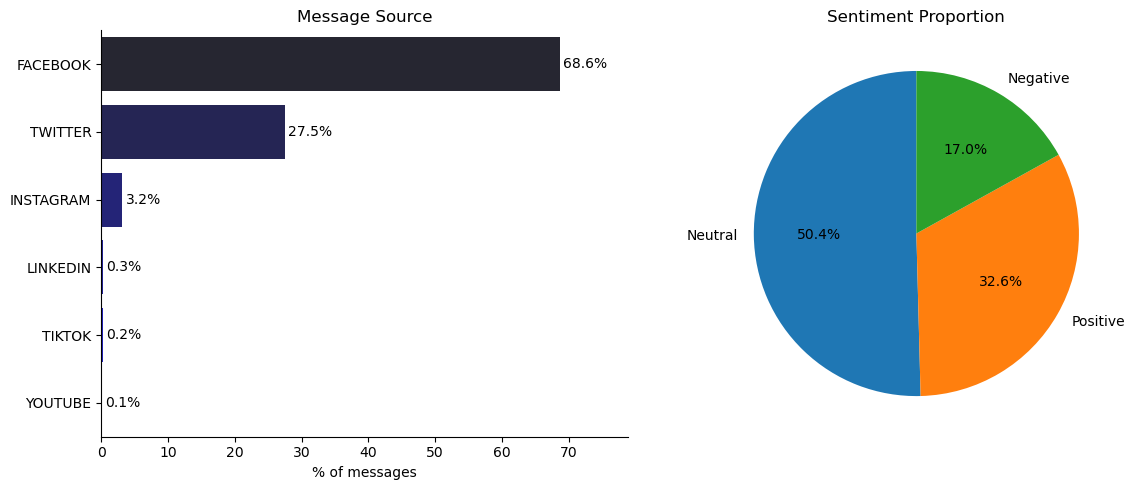

In [9]:
# Before we pass the data for ML we need to understand messages distribution, 
# This helps to ensure that the model is trained fairly

platform_counts = df_sent['snTypeColumn'].value_counts()
platform_pct = (platform_counts / platform_counts.sum() * 100).reset_index()
platform_pct.columns = ['Platform', 'percentage']
platform_pct = platform_pct.sort_values('percentage', ascending=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=platform_pct, x='percentage', y='Platform', ax=ax[0], hue='Platform', palette='dark:b_r', legend=False)
sns.despine() # remove top and right spines
ax[0].set_title('Message Source')
ax[0].set_xlabel('% of messages')
ax[0].set_ylabel('')
ax[0].set_xlim(0, platform_pct['percentage'].max() * 1.15)
ax[0].invert_yaxis()

for n, v in enumerate(platform_pct['percentage']):
    ax[0].text(v + 0.5, n, f'{v:.1f}%', va='center')

df_sent['Sentiment'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%', ax=ax[1], ylabel='', title='Sentiment Proportion')

fig.tight_layout()
plt.show()

##### Top platform contributor by sentiment

In [10]:
df_Plat = df_sent.groupby(['Sentiment','snTypeColumn'])['Conversation Stream'].size().reset_index()
df_Plat.columns = ['Sentiment','Social_Channel','messages']

df_Plat.head()

,Sentiment,Social_Channel,messages
0,Negative,FACEBOOK,3098
1,Negative,INSTAGRAM,139
2,Negative,LINKEDIN,23
3,Negative,TIKTOK,17
4,Negative,TWITTER,663


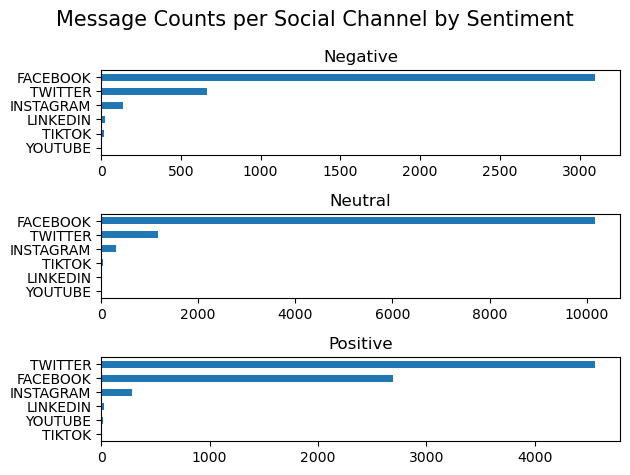

In [11]:
sentiments =  df_Plat['Sentiment'].unique()   #Just getting sentiment attributes(POS,NEG,NEU)
#Plot the graph in message counts
fig, ax = plt.subplots(len(sentiments), 1)

for i, sentiments in enumerate(sentiments):
    df_plot = df_Plat[df_Plat['Sentiment'] == sentiments].sort_values('messages',ascending=True)
    df_plot.plot(kind='barh', x='Social_Channel', y='messages', ax=ax[i], title=sentiments)
    # ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Message Counts per Social Channel by Sentiment', fontsize=15)
fig.tight_layout()
plt.show()


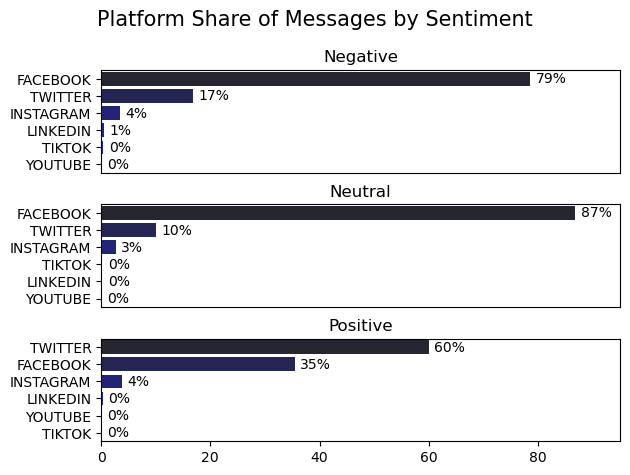

In [12]:
#A percentage representation of the above graph

sentiments = df_Plat['Sentiment'].unique()
fig, ax = plt.subplots(len(sentiments), 1)

for i, sentiment in enumerate(sentiments):
    dp_perc = df_Plat[df_Plat['Sentiment'] == sentiment].copy()
    dp_perc['percentage'] = dp_perc['messages'] / dp_perc['messages'].sum() * 100
    dp_perc = dp_perc.sort_values('percentage', ascending=True)
    sns.barplot(data=dp_perc, x='percentage', y='Social_Channel', ax=ax[i], hue='Social_Channel', palette='dark:b_r')
    ax[i].set_title(sentiment)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].invert_yaxis()
    # ax[i].get_legend().remove()
    ax[i].set_xlim(0, 95)
    
    # remove the x-axis tick labels for better readability
    if i != len(sentiments) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(dp_perc['percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Platform Share of Messages by Sentiment', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()

#### 2) ML & Feature engineering

##### - Renaming columns of interest
##### - Creating a balanced dataset
##### - Doing text-processing
##### - Setting up a pipeline
##### - Evaluting the model performance

In [13]:
#date cleaning
df_ML = df_sent.copy()
df_ML = df_ML.rename(columns= {'Conversation Stream':'message','snTypeColumn':'channel', 'Created Time': 'date'})
df_ML['date'] = pd.to_datetime(df_ML['date']).dt.date

In [14]:
# creating a balanced dataset
def balanced_sample(df, target_n):
    group_col= 'Sentiment'
    
    parts = []
    for value, group in df.groupby(group_col):
        parts.append(group.sample(n=min(len(group), target_n)))
    return pd.concat(parts).reset_index(drop=True)

df_balanced = balanced_sample(df_ML, 3500)
print(df_balanced['Sentiment'].value_counts())


Sentiment
Negative    3500
Neutral     3500
Positive    3500
Name: count, dtype: int64


In [15]:
# Text processing

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Safety check for empty or missing data
    if not isinstance(text, str):
        return ''

    # 2. Fix messy web text (e.g., &#39; to ')
    text = html.unescape(text)

    # 3. Remove URLs and @mentions (we don't want to translate these!)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # 4. PRESERVE EMOJIS: Translate them into words, then remove the colons
    text = emoji.demojize(text)
    text = text.replace(':', ' ')

    # 5. Fix spacing by turning newlines into regular spaces
    text = text.replace('\\n', ' ').replace('\n', ' ')

    # 6. Lowercase everything for consistency
    text = text.lower()

    # 7. Remove junk: Keep only letters and spaces (Emoji text survives this safely!)
    text = re.sub(r'[^a-zA-ZÀ-ÿ\s]', ' ', text)
    
    # 8. Squash double/triple spaces down to a single space
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Tokenize: Chop the string into individual words
    tokens = word_tokenize(text)

    # 10. Filter & Lemmatize: Remove stop words, drop single letters, and shrink to root words
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]

    # 11. Reassemble into a perfectly clean string ready for ML
    return ' '.join(tokens)

In [16]:
df_balanced['message_clean'] = df_balanced['message'].apply(clean_text)

In [17]:
empty_after_clean = (df_balanced['message_clean'].str.strip() == '').sum()
print(f"{empty_after_clean} rows became empty after cleaning")

821 rows became empty after cleaning


In [18]:
df_balanced = df_balanced[df_balanced['message_clean'].str.strip() != '']

In [19]:
# using Logistic regression as a classifier
X_train, X_test, y_train, y_test = train_test_split(        #X being the input data - messages
    df_balanced['message_clean'],
    df_balanced['Sentiment'],
    test_size=0.2,
    stratify=df_balanced['Sentiment'],
    random_state=42
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


In [20]:
# fitting and making predictions
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [21]:
# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.77      0.85      0.81       698
     Neutral       0.75      0.75      0.75       579
    Positive       0.96      0.86      0.91       659

    accuracy                           0.82      1936
   macro avg       0.83      0.82      0.82      1936
weighted avg       0.83      0.82      0.83      1936



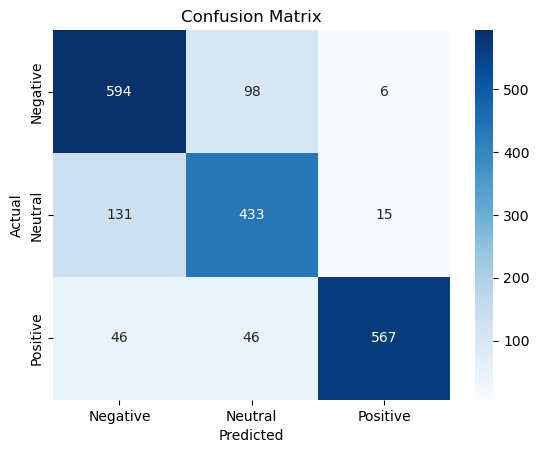

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

##### using Random Forest as a classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(        #X being the input data - messages
    df_balanced['message_clean'],
    df_balanced['Sentiment'],
    test_size=0.2,
    stratify=df_balanced['Sentiment'],
    random_state=42
)


pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Fit
pipeline_rf.fit(X_train, y_train)

# Predict
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82       698
     Neutral       0.76      0.78      0.77       579
    Positive       0.96      0.86      0.91       659

    accuracy                           0.83      1936
   macro avg       0.84      0.83      0.83      1936
weighted avg       0.84      0.83      0.83      1936



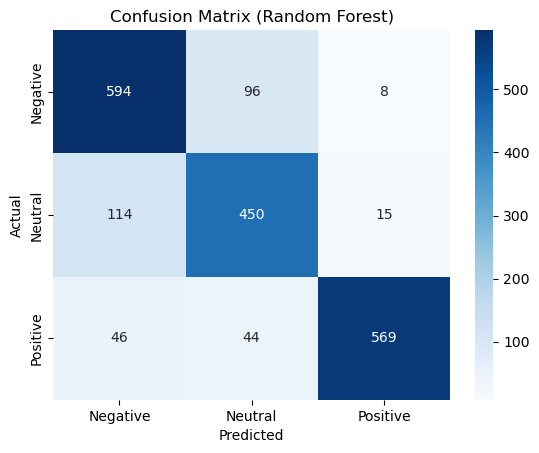

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=pipeline_rf.classes_)
sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=pipeline_rf.classes_, yticklabels=pipeline_rf.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

##### comparing the two algorithms

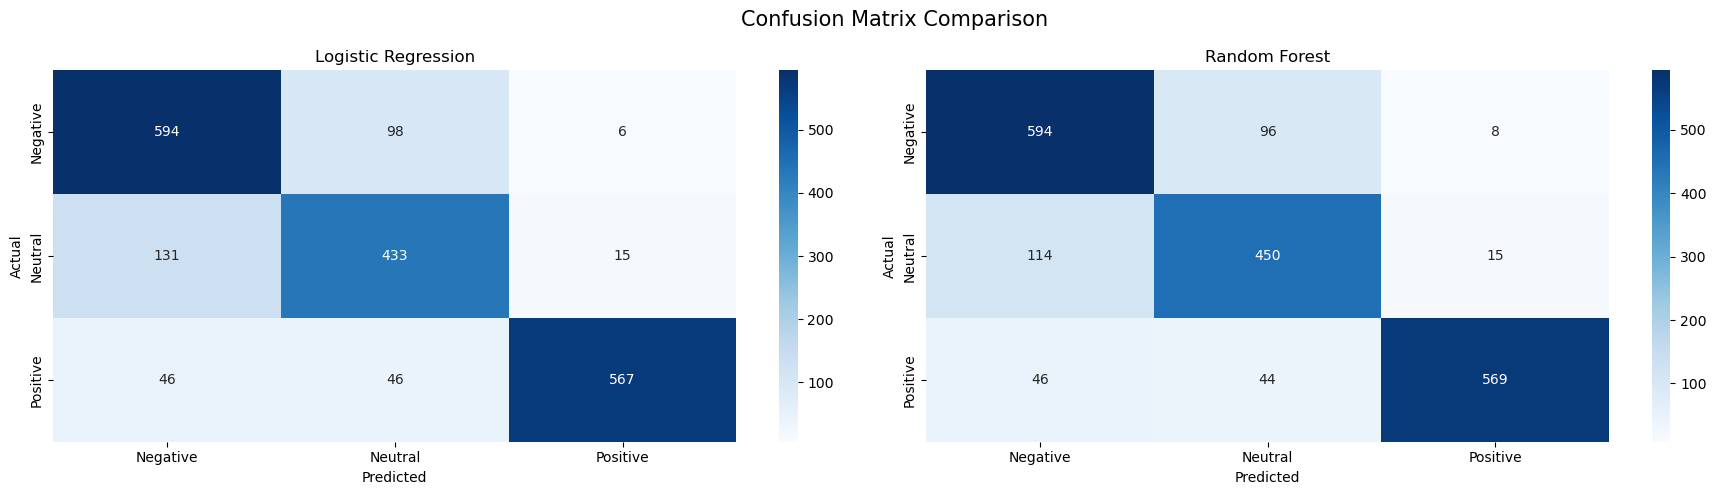

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

models = {
    'Logistic Regression': (pipeline, y_pred),
    'Random Forest': (pipeline_rf, y_pred_rf)
}

for ax, (name, (model, preds)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrix Comparison', fontsize=15)
fig.tight_layout()
plt.show()